<a href="https://colab.research.google.com/github/Anmolrbd/FDS_Lab/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.4 MB/s eta 0:00:00


         Date  CustomerID  Product   Category    Sales
0  2026-01-27      1243.0    Phone   Clothing  1244.20
1  2024-02-28      9530.0     None       Toys      NaN
2  2020-07-10      6917.0   Laptop   Clothing   924.63
3  2023-09-26      5297.0  Monitor  Furniture  1009.68
4  2023-01-02      4922.0  Monitor     Sports   895.25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        95 non-null     object 
 1   CustomerID  98 non-null     float64
 2   Product     93 non-null     object 
 3   Category    105 non-null    object 
 4   Sales       92 non-null     float64
dtypes: float64(2), object(3)
memory usage: 4.2+ KB
None

Missing Values:
 Date          10
CustomerID     7
Product       12
Category       0
Sales         13
dtype: int64

Summary Statistics:
                       Date   CustomerID        Sales         Year      Month  \
coun

/tmp/ipykernel_6502/670690103.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].median(), inplace=True)


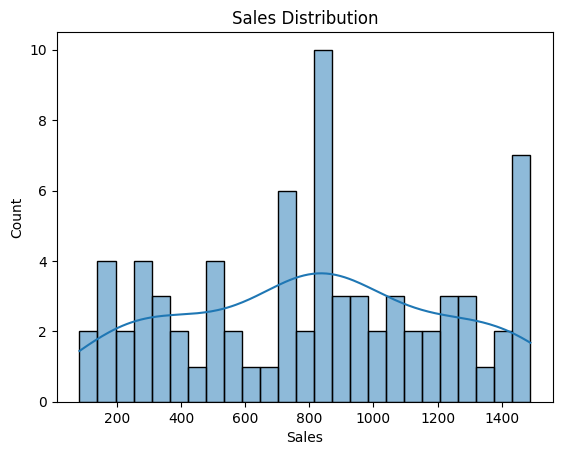

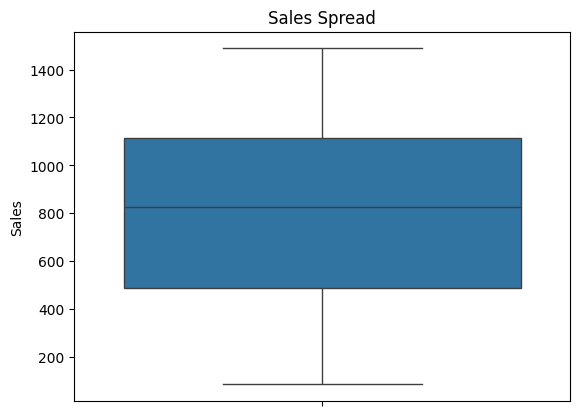

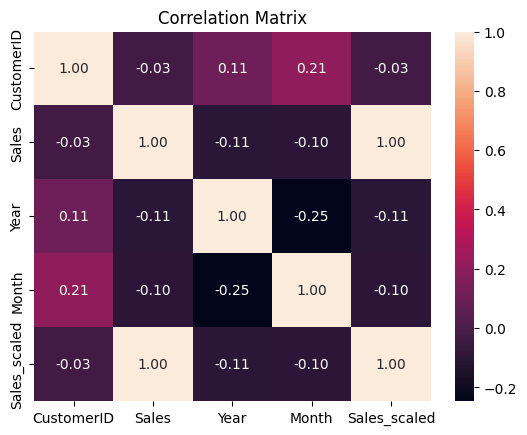

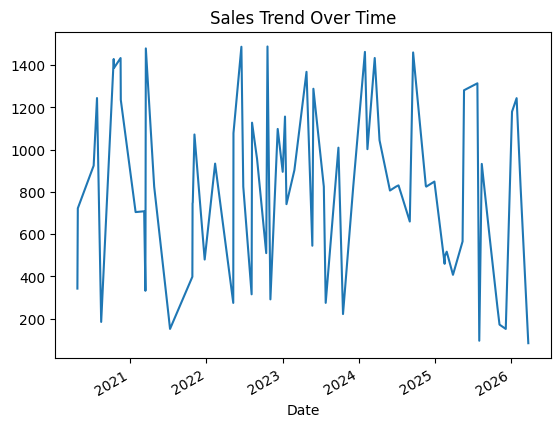

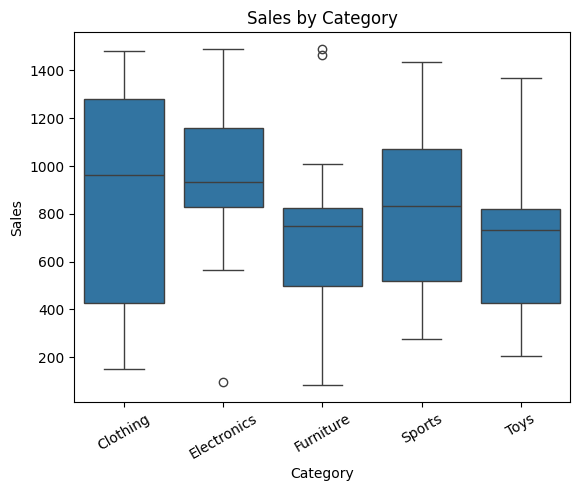

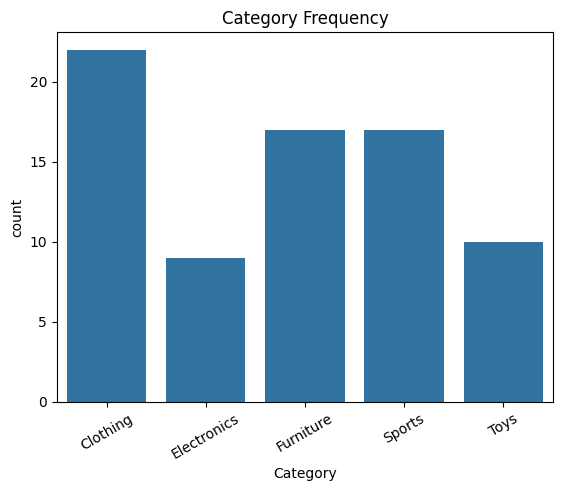

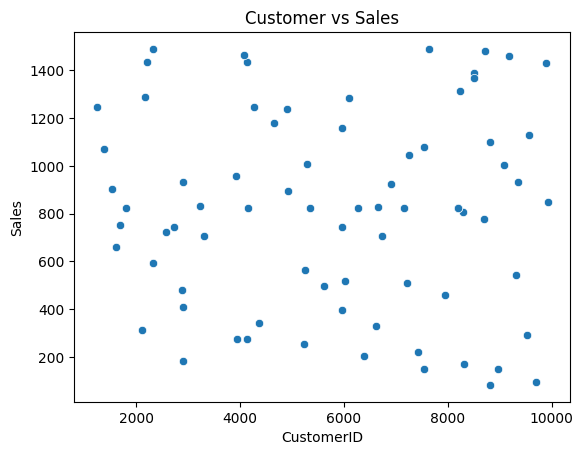

In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker


faker = Faker()
np.random.seed(10)
random.seed(10)

def create_dataset(size=100):
    records = []

    products = ['Laptop', 'Phone', 'Tablet', 'Monitor', 'Keyboard', 'Headphones', 'Mouse']
    categories = ['Electronics', 'Furniture', 'Toys', 'Clothing', 'Sports']

    for _ in range(size):
        record = {
            "Date": faker.date_this_decade() if random.random() > 0.1 else None,
            "CustomerID": random.randint(1000, 9999) if random.random() > 0.05 else None,
            "Product": random.choice(products),
            "Category": random.choice(categories),
            "Sales": round(random.uniform(50, 1500), 2) if random.random() > 0.1 else None
        }
        records.append(record)

    df = pd.DataFrame(records)


    mask = np.random.rand(len(df)) < 0.1
    df.loc[mask, 'Product'] = None


    df = pd.concat([df, df.sample(frac=0.05)], ignore_index=True)

    return df


df = create_dataset()
df.to_csv("sales_data.csv", index=False)

print(df.head())
print(df.info())


df = pd.read_csv("sales_data.csv")

print("\nMissing Values:\n", df.isnull().sum())


df['Sales'].fillna(df['Sales'].median(), inplace=True)


df.dropna(inplace=True)


df['Date'] = pd.to_datetime(df['Date'])
df['Category'] = df['Category'].astype('category')


df.drop_duplicates(inplace=True)
df.drop_duplicates(subset=['CustomerID', 'Product'], inplace=True)


df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Sales_scaled'] = scaler.fit_transform(df[['Sales']])


df.to_csv("cleaned_sales_data.csv", index=False)


print("\nSummary Statistics:\n", df.describe())
print("\nCategory Counts:\n", df['Category'].value_counts())


import matplotlib.pyplot as plt
import seaborn as sns


plt.figure()
sns.histplot(df['Sales'], bins=25, kde=True)
plt.title("Sales Distribution")
plt.show()


plt.figure()
sns.boxplot(y=df['Sales'])
plt.title("Sales Spread")
plt.show()


plt.figure()
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


plt.figure()
df.groupby('Date')['Sales'].sum().plot()
plt.title("Sales Trend Over Time")
plt.show()


plt.figure()
sns.boxplot(x='Category', y='Sales', data=df)
plt.xticks(rotation=30)
plt.title("Sales by Category")
plt.show()


plt.figure()
sns.countplot(data=df, x='Category')
plt.xticks(rotation=30)
plt.title("Category Frequency")
plt.show()


plt.figure()
sns.scatterplot(x='CustomerID', y='Sales', data=df)
plt.title("Customer vs Sales")
plt.show()